In [4]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from Conv_Layer import Conv_Layer, convolve
from Pool_Layer import Pool_Layer
from Flatten import Flatten
from Dense_Layer import Dense_Layer
from Softmax import Softmax
from ReLU import ReLU
from Network import Network, loss_grad, cross_entropy, accuracy


In [5]:
data = np.load('mnist.npz')
X_train, y_train, X_test, y_test = data['x_train'], data['y_train'], data['x_test'], data['y_test']
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0
X_train = X_train[..., None]
X_test = X_test[..., None]

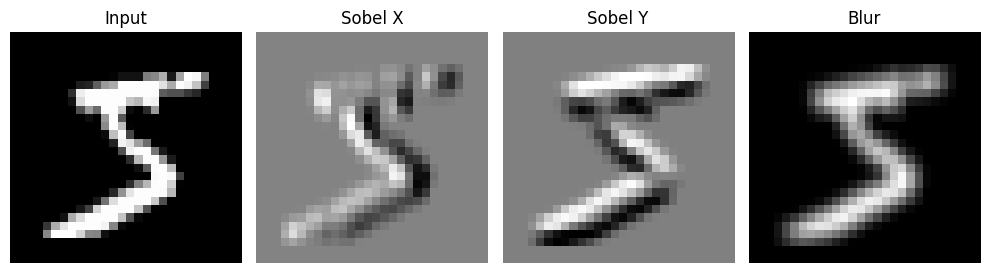

In [47]:
# Pick one sample
img = X_train[0:1]  # shape (1, 28, 28, 1) - need batch dimension

# Create a few simple filters (K=3, C_in=1, C_out=3)
K = 3
C_in = 1
C_out = 3
# Example filters: edge detectors and blur
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1,-2,-1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]], dtype=np.float32)
blur = (1/9) * np.ones((3,3), dtype=np.float32)

# Stack into kernel of shape (K, K, C_in, C_out)
kernel = np.zeros((K, K, C_in, C_out), dtype=np.float32)
kernel[:, :, 0, 0] = sobel_x
kernel[:, :, 0, 1] = sobel_y
kernel[:, :, 0, 2] = blur

bias = np.zeros((C_out,), dtype=np.float32)
stride = 1
padding = 1  # to keep output 28x28 for K=3, stride=1

out, _ = convolve(img, kernel, bias, stride, padding)  # shape (28, 28, 3)

# Plot input and outputs
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes[0].imshow(img[0].squeeze(), cmap='gray')
axes[0].set_title('Input')
axes[0].axis('off')

titles = ['Sobel X', 'Sobel Y', 'Blur']
for i in range(C_out):
    axes[i+1].imshow(out[0, :, :, i], cmap='gray')
    axes[i+1].set_title(titles[i])
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

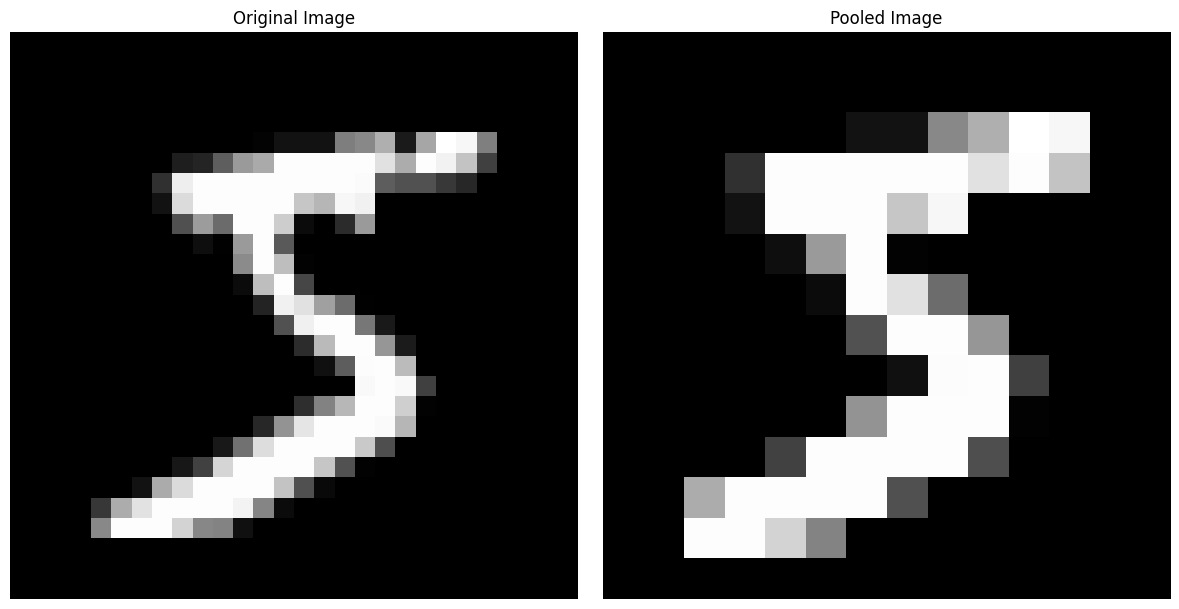

In [46]:
# Pooling test
img = X_train[0:1]  # Need batch dimension
pool_layer = Pool_Layer()
pooled = pool_layer.forward(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img[0].squeeze(), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(pooled[0].squeeze(), cmap='gray')
axes[1].set_title('Pooled Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [48]:
# Flatten layer test
print("=" * 50)
print("Flatten Layer Test")
print("=" * 50)

flatten_layer = Flatten()
test_input = X_train[0:1]  # Shape: (1, 28, 28, 1) - need batch dimension
print(f"Input shape: {test_input.shape}")

# Forward pass
flattened = flatten_layer.forward(test_input)
print(f"Flattened shape: {flattened.shape}")
print(f"Expected size: {np.prod(test_input.shape)}")
print(f"Sizes match: {flattened.size == np.prod(test_input.shape)}")

# Backward pass
dout = np.random.randn(*flattened.shape) * 0.1
unflattened = flatten_layer.backward(dout)
print(f"\nGradient input shape: {dout.shape}")
print(f"Unflattened shape: {unflattened.shape}")
print(f"Shapes match: {unflattened.shape == test_input.shape}")

# Verify round-trip test (forward then backward with identity gradient)
flattened_again = flatten_layer.forward(test_input)
reconstructed = flatten_layer.backward(flattened_again)
print(f"\nRound-trip test (forward -> backward with identity): {np.allclose(test_input, reconstructed)}")


Flatten Layer Test
Input shape: (1, 28, 28, 1)
Flattened shape: (1, 784)
Expected size: 784
Sizes match: True

Gradient input shape: (1, 784)
Unflattened shape: (1, 28, 28, 1)
Shapes match: True

Round-trip test (forward -> backward with identity): True


In [7]:
from Network import Network

In [52]:
net = Network([
    Conv_Layer(1, 16),
    Pool_Layer(),
    Conv_Layer(16, 32),
    Pool_Layer(),
    Flatten(),
    Dense_Layer(800, 256),
    Dense_Layer(256, 10, 'softmax')
])

net.train(X_train, y_train, 128, 8)

Epoch 1: Accuracy = 0.84465, Loss = 0.5489611174869917
Epoch 2: Accuracy = 0.9362, Loss = 0.2130319351321316
Epoch 3: Accuracy = 0.9532, Loss = 0.15882951401636786
Epoch 4: Accuracy = 0.9618833333333333, Loss = 0.12989812289635294
Epoch 5: Accuracy = 0.9673666666666667, Loss = 0.1115759386649911
Epoch 6: Accuracy = 0.9711, Loss = 0.0988393807408771
Epoch 7: Accuracy = 0.9737833333333333, Loss = 0.08933330406585843
Epoch 8: Accuracy = 0.9761666666666666, Loss = 0.08180406975299243


In [ ]:
acc, loss = net.evaluate(X_test, y_test)
print('Accuracy:', acc, 'Loss:', loss)

Accuracy: 0.9754 Loss: 0.07735994302606777


In [6]:
# PyTorch CNN with same structure as scratch implementation
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Create model matching the structure from Cell 7:
# Conv_Layer(1, 16) -> Conv2d(1, 16, 3x3, ReLU)
# Pool_Layer() -> MaxPool2d(2x2)
# Conv_Layer(16, 32) -> Conv2d(16, 32, 3x3, ReLU)
# Pool_Layer() -> MaxPool2d(2x2)
# Flatten() -> view/flatten
# Dense_Layer(800, 256) -> Linear(800, 256, ReLU)
# Dense_Layer(256, 10, 'softmax') -> Linear(256, 10)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First Conv Layer: 1 input channel -> 16 output channels, 3x3 kernel, no padding
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=0)
        # First Pooling Layer: 2x2 max pooling with stride 2
        self.pool1 = nn.MaxPool2d(2, stride=2)
        # Second Conv Layer: 16 input channels -> 32 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        # Second Pooling Layer: 2x2 max pooling with stride 2
        self.pool2 = nn.MaxPool2d(2, stride=2)
        # Flatten layer
        # First Dense Layer: 800 input -> 256 output, ReLU
        self.fc1 = nn.Linear(800, 256)  # 5*5*32 = 800 after two pooling layers
        # Output Layer: 256 input -> 10 output
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)  # Flatten: (batch, 5, 5, 32) -> (batch, 800)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Softmax applied in loss function
        return x

# Create model
pytorch_model = CNN()
print("PyTorch Model Architecture:")
print(pytorch_model)

# Convert numpy arrays to PyTorch tensors
# PyTorch uses NCHW format (batch, channels, height, width)
# Your data is in NHWC format (batch, height, width, channels), so we need to permute
X_train_tensor = torch.FloatTensor(X_train).permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test).permute(0, 3, 1, 2)
y_test_tensor = torch.LongTensor(y_test)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Training setup
criterion = nn.CrossEntropyLoss()  # Includes softmax
optimizer = optim.Adam(pytorch_model.parameters())

# Train the model (matching the training setup from Cell 7)
print("\nTraining PyTorch model...")
pytorch_model.train()
for epoch in range(8):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = pytorch_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    accuracy = correct / total
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch {epoch+1}: Accuracy = {accuracy:.5f}, Loss = {avg_loss:.5f}')

# Evaluate on test set
pytorch_model.eval()
with torch.no_grad():
    test_outputs = pytorch_model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor).item()
    _, predicted = torch.max(test_outputs, 1)
    test_accuracy = (predicted == y_test_tensor).float().mean().item()

print(f'\nPyTorch Model - Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}')


PyTorch Model Architecture:
CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

Training PyTorch model...
Epoch 1: Accuracy = 0.91132, Loss = 0.30754
Epoch 2: Accuracy = 0.97823, Loss = 0.07241
Epoch 3: Accuracy = 0.98562, Loss = 0.04887
Epoch 4: Accuracy = 0.98870, Loss = 0.03770
Epoch 5: Accuracy = 0.99078, Loss = 0.03016
Epoch 6: Accuracy = 0.99203, Loss = 0.02558
Epoch 7: Accuracy = 0.99390, Loss = 0.01971
Epoch 8: Accuracy = 0.99503, Loss = 0.01619

PyTorch Model - Test Accuracy: 0.9903, Test Loss: 0.0295
